# Data Cleaning and Preparation

## Handling Missing Data

In [1]:
import numpy as np
import pandas as pd

In [ ]:
# jika ada data dengan float64 dytype, pandas akan menggunakan NaN(not a Number) untuk menandai data yang hilang.
# Kita menyebut ini sebagai sentinel value: jika muncul, menandakan sebuah kehilangan(atau null) suatu nilai
float_data = pd.Series([3.2, -2.5, np.nan, 1])
print(f"datasets dengan missing value:\n{float_data}\n")
# dengan isna, kita dapat mencari missing value dengan nilai boolean, dimana True = data hilang, False = data ada
print(f"mencari dengan isna:\n{float_data.isna()}\n")
# di pandas, kita mengnna NA(not available) sama seperti di R, dalam statistik ini berati data hilang atau tidak terobservasi
# dalam built in python, missing value ditandai none

datasets dengan missing value:
0    3.2
1   -2.5
2    NaN
3    1.0
dtype: float64

mencari dengan isna:
0    False
1    False
2     True
3    False
dtype: bool



### Berikut tabel list fungsi yang digunakan untuk menangani missing value di pandas:
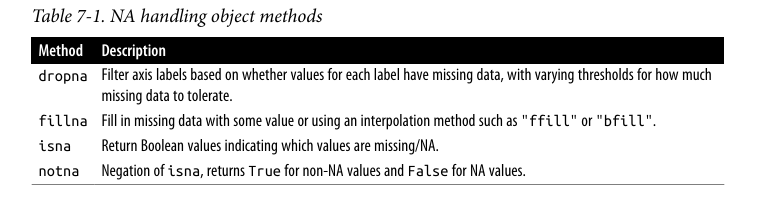

### Filtering Out Missing Data

In [ ]:
# dari pada kita mencari dengan menggunakan isna lalu memfilter, kita dapat menggunakan method dropna()
# misal kita punya suatu data series
series1 = pd.Series([32, 14, np.nan, 2, 5.4, np.nan, 0])
print(f"data series:\n{series1}\n")
# dengan dropna pada series, dia akan menghapus baris yang NaN
series1_dropped = series1.dropna()
print(f"data series setelah menghapus missing value:\n{series1_dropped}\n")
# atau bisa juga dengan kurung siku: series1[series1.notna()]

data series:
0    32.0
1    14.0
2     NaN
3     2.0
4     5.4
5     NaN
6     0.0
dtype: float64

data series setelah menghapus missing value:
0    32.0
1    14.0
3     2.0
4     5.4
6     0.0
dtype: float64



In [11]:
# bila kita punya dataframe
frame1 = pd.DataFrame([[32, 14, 2.7], [1, np.nan, np.nan], [np.nan, np.nan, np.nan], [np.nan, 12, 7.8]])
print(f"dataframe:\n{frame1}\n")
# secara default, dropna akan menghapus seluruh baris yang memiliki missing value
frame1_dropped_default = frame1.dropna()
print(f"dataframe setelah menghapus missing value:\n{frame1_dropped_default}\n")
# bila ingin menggunakan dropna untuk menghapus kolom, kita bisa menggunakan argumen axis=1 atau axis='columns'
frame1_dropped_default_columns = frame1.dropna(axis='columns')
print(f"dataframe setelah menghapus missing value di kolom:\n{frame1_dropped_default_columns}\n")
# bisa dibilang argumen defautl how='any' artinya jika ada missing value di baris tersebut, maka baris itu akan dihapus

# bila hanya baris/kolom dengan keseluruhan missing value yang dihapus, maka kita bisa menggunakan how='all'
frame1_dropped_all = frame1.dropna(how='all') # hanya baris full missing value yang dihapus
print(f"dataframe setelah menghapus missing value dengan how='all':\n{frame1_dropped_all}\n")

# bila ingin memasukan baris/kolom dengan value valid tertentu, kita bisa menggunakan argumen thresh
frame1_dropped_thresh_2 = frame1.dropna(thresh=2) # hanya baris dengan minimal 2 data yang ada yang akan dipertahankan
print(f"dataframe khusus data tercatat minimal 2:\n{frame1_dropped_thresh_2}\n")

dataframe:
      0     1    2
0  32.0  14.0  2.7
1   1.0   NaN  NaN
2   NaN   NaN  NaN
3   NaN  12.0  7.8

dataframe setelah menghapus missing value:
      0     1    2
0  32.0  14.0  2.7

dataframe setelah menghapus missing value di kolom:
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3]

dataframe setelah menghapus missing value dengan how='all':
      0     1    2
0  32.0  14.0  2.7
1   1.0   NaN  NaN
3   NaN  12.0  7.8

dataframe khusus data tercatat minimal 2:
      0     1    2
0  32.0  14.0  2.7
3   NaN  12.0  7.8



### Filling In Missing Data

In [13]:
# bila kita tidak ingin membuang data, kita bisa mengisi NaN dengan fungsi fillna
series1_filled = series1.fillna(0) # data NaN akan diganti dengan 0
print(f"data series setelah mengisi missing value dengan 0:\n{series1_filled}\n")

data series setelah mengisi missing value dengan 0:
0    32.0
1    14.0
2     0.0
3     2.0
4     5.4
5     0.0
6     0.0
dtype: float64



In [15]:
# pada dataframe, kita bisa mengisi missing value dengan nilai tertentu, misal 0
frame1_filled_0 = frame1.fillna(0)
print(f"dataframe setelah mengisi missing value dengan 0:\n{frame1_filled_0}\n")

# atau kita ingin tiap NaN memiliki nilai berrbeda pada kolom tertentu, kita bisa menggunakan dictionary
frame1_filled_different = frame1.fillna({0:1, 1:3, 2:5}) # kolom 0 diisi dengan 1, kolom 1 diisi dengan 3, kolom 2 diisi dengan 5
print(f"dataframe setelah mengisi missing value dengan dictionary:\n{frame1_filled_different}\n")

dataframe setelah mengisi missing value dengan 0:
      0     1    2
0  32.0  14.0  2.7
1   1.0   0.0  0.0
2   0.0   0.0  0.0
3   0.0  12.0  7.8

dataframe setelah mengisi missing value dengan dictionary:
      0     1    2
0  32.0  14.0  2.7
1   1.0   3.0  5.0
2   1.0   3.0  5.0
3   1.0  12.0  7.8



In [17]:
# misal kita punya df lain
df = pd.DataFrame(np.random.standard_normal((8, 4)))
df.iloc[3:6, 1] = np.nan
df.iloc[6:, 3] = np.nan
print(f"dataframe:\n{df}\n")

dataframe:
          0         1         2         3
0  0.455274 -0.168393  3.066610  0.709425
1  0.536074  2.120964  0.384971  2.560523
2 -0.847542 -0.733512 -0.976137 -1.282486
3 -1.082346       NaN -1.565955 -2.975717
4  0.601898       NaN -0.938037 -1.878194
5 -0.775450       NaN  0.196510 -0.410017
6 -0.698913 -0.426606  0.433350       NaN
7  0.726308 -0.038636 -0.846708       NaN



In [20]:
# kita bisa menggunakan method forward fill, yaitu mengisi missing value dengan nilai sebelumnya menurunin kolom
df_filled_ffill = df.ffill()
print(f"dataframe setelah mengisi missing value dengan forward fill:\n{df_filled_ffill}\n")
# atau menaiki kolom dengan back fill
df_filled_bfill = df.bfill()
print(f"dataframe setelah mengisi missing value dengan back fill:\n{df_filled_bfill}\n")

dataframe setelah mengisi missing value dengan forward fill:
          0         1         2         3
0  0.455274 -0.168393  3.066610  0.709425
1  0.536074  2.120964  0.384971  2.560523
2 -0.847542 -0.733512 -0.976137 -1.282486
3 -1.082346 -0.733512 -1.565955 -2.975717
4  0.601898 -0.733512 -0.938037 -1.878194
5 -0.775450 -0.733512  0.196510 -0.410017
6 -0.698913 -0.426606  0.433350 -0.410017
7  0.726308 -0.038636 -0.846708 -0.410017

dataframe setelah mengisi missing value dengan back fill:
          0         1         2         3
0  0.455274 -0.168393  3.066610  0.709425
1  0.536074  2.120964  0.384971  2.560523
2 -0.847542 -0.733512 -0.976137 -1.282486
3 -1.082346 -0.426606 -1.565955 -2.975717
4  0.601898 -0.426606 -0.938037 -1.878194
5 -0.775450 -0.426606  0.196510 -0.410017
6 -0.698913 -0.426606  0.433350       NaN
7  0.726308 -0.038636 -0.846708       NaN



In [22]:
# kita juga bisa menggunakan argumen axis
# misal kita ingin ffill ke samping, maka kita bisa menggunakan axis=1 atau axis='columns'
df_filled_ffill_axis1 = df.ffill(axis='columns')
print(f"dataframe setelah mengisi missing value dengan forward fill ke samping:\n{df_filled_ffill_axis1}\n")

dataframe setelah mengisi missing value dengan forward fill ke samping:
          0         1         2         3
0  0.455274 -0.168393  3.066610  0.709425
1  0.536074  2.120964  0.384971  2.560523
2 -0.847542 -0.733512 -0.976137 -1.282486
3 -1.082346 -1.082346 -1.565955 -2.975717
4  0.601898  0.601898 -0.938037 -1.878194
5 -0.775450 -0.775450  0.196510 -0.410017
6 -0.698913 -0.426606  0.433350  0.433350
7  0.726308 -0.038636 -0.846708 -0.846708



In [ ]:
# bila ingin membatasi jumlah nilai yang diisi, kita bisa menggunakan argumen limit
df_filled_ffill_limit2 = df.ffill(limit=2)
print(f"dataframe setelah mengisi missing value dengan forward fill dengan limit 2:\n{df_filled_ffill_limit2}\n")

# atau kita ingin mengisi NaN dengan metode statistik, misal mean, median, atau modus cukup tambahkan method kedalam fillna
df_filled_mean = df.fillna(df.mean(), limit=2) # mengisi NaN dengan mean tiap kolom, dengan limit 2
print(f"dataframe setelah mengisi missing value dengan mean tiap kolom:\n{df_filled_mean}\n")

dataframe setelah mengisi missing value dengan forward fill dengan limit 2:
          0         1         2         3
0  0.455274 -0.168393  3.066610  0.709425
1  0.536074  2.120964  0.384971  2.560523
2 -0.847542 -0.733512 -0.976137 -1.282486
3 -1.082346 -0.733512 -1.565955 -2.975717
4  0.601898 -0.733512 -0.938037 -1.878194
5 -0.775450       NaN  0.196510 -0.410017
6 -0.698913 -0.426606  0.433350 -0.410017
7  0.726308 -0.038636 -0.846708 -0.410017

dataframe setelah mengisi missing value dengan mean tiap kolom:
          0         1         2         3
0  0.455274 -0.168393  3.066610  0.709425
1  0.536074  2.120964  0.384971  2.560523
2 -0.847542 -0.733512 -0.976137 -1.282486
3 -1.082346  0.150763 -1.565955 -2.975717
4  0.601898  0.150763 -0.938037 -1.878194
5 -0.775450       NaN  0.196510 -0.410017
6 -0.698913 -0.426606  0.433350 -0.546078
7  0.726308 -0.038636 -0.846708 -0.546078



#### berikut tabel metode fill
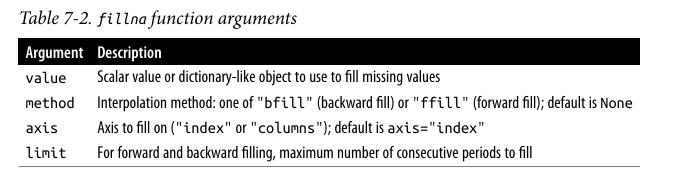

## Data Transformation

### Removing Duplicates

In [26]:
# misal kita punya data
data = pd.DataFrame({"k1": ["one", "two"] * 3 + ["two"],
                      "k2": [1, 1, 2, 5, 5, 8, 8]})
print(f"data:\n{data}\n")

data:
    k1  k2
0  one   1
1  two   1
2  one   2
3  two   5
4  one   5
5  two   8
6  two   8



In [ ]:
# kita bisa menggunakan duplicated untuk mencari data yang duplikat, true=data duplikat, false=data unik
data_duplicated = data.duplicated()
print(f"data duplikat:\n{data_duplicated}\n")
# bila ingin langsung menghapus data duplikat, kita bisa menggunakan drop_duplicates
data_duplicate_dropped = data.drop_duplicates()
print(f"data setelah menghapus data duplikat:\n{data_duplicate_dropped}\n")
# secara default, akan menyisir baris

data duplikat:
0    False
1    False
2    False
3    False
4    False
5    False
6     True
dtype: bool

data setelah menghapus data duplikat:
    k1  k2
0  one   1
1  two   1
2  one   2
3  two   5
4  one   5
5  two   8



In [30]:
# kita bisa mengecek kolom tertentu saja
# mari kita tambahkan kolom baru
data["k3"] = range(7)
print(f"data:\n{data}\n")

data:
    k1  k2  k3
0  one   1   0
1  two   1   1
2  one   2   2
3  two   5   3
4  one   5   4
5  two   8   5
6  two   8   6



In [ ]:
# lalu kita bisa mengecek duplikat pada kolom k1 saja dengan menggunakan subset
data_duplicated_k1 = data.duplicated(subset="k1")
print(f"data duplikat pada kolom k1:\n{data_duplicated_k1}\n")
# atau drop duplikat pada kolom k1 saja
data_duplicate_dropped_k1 = data.drop_duplicates(subset="k1")
print(f"data setelah menghapus duplikat pada kolom k1:\n{data_duplicate_dropped_k1}\n")

data duplikat pada kolom k1:
0    False
1    False
2     True
3     True
4     True
5     True
6     True
dtype: bool

data setelah menghapus duplikat pada kolom k1:
    k1  k2  k3
0  one   1   0
1  two   1   1



In [44]:
# karena dibaca dari atas ke bawah, maka data yang dipertahankan adalah data yang pertama kali muncul, bila ingin mempertahankan data terakhir
# bila ingin mempertahankan data terakhir, kita bisa menggunakan argumen keep='last'
data_duplicate_dropped_last = data.drop_duplicates(['k1', 'k2'], keep = 'last')
print(f"data setelah menghapus duplikat pada kolom k1 dan k2, mempertahankan data terakhir:\n{data_duplicate_dropped_last}\n")
# atau bila ingin menghapus seluruh baris duplikat, kita bisa menggunakan keep=False
data_keep_false = data.drop_duplicates(['k1', 'k2'], keep = False)
print(f"data setelah menghapus seluruh baris terduplikat pada kolom k1 dan k2:\n{data_keep_false}\n")

data setelah menghapus duplikat pada kolom k1 dan k2, mempertahankan data terakhir:
    k1  k2  k3
0  one   1   0
1  two   1   1
2  one   2   2
3  two   5   3
4  one   5   4
6  two   8   6

data setelah menghapus seluruh baris terduplikat pada kolom k1 dan k2:
    k1  k2  k3
0  one   1   0
1  two   1   1
2  one   2   2
3  two   5   3
4  one   5   4



### Transforming Data Using a Function or Mapping

In [48]:
# misal kita punya data
data = pd.DataFrame({"food": ["bacon", "pulled pork", "bacon", "pastrami", "corned beef", "bacon", "pastrami", "honey ham", "nova lox"],
                     "ounces": [4, 3, 12, 6, 7.5, 8, 3, 5, 6]})
print(f"data:\n{data}\n")

data:
          food  ounces
0        bacon     4.0
1  pulled pork     3.0
2        bacon    12.0
3     pastrami     6.0
4  corned beef     7.5
5        bacon     8.0
6     pastrami     3.0
7    honey ham     5.0
8     nova lox     6.0



In [49]:
# kita ingin tiap daging disesuaikan dengan hewannya, kita bisa menggunakan dictionary mapping, misal:
meat_to_animal = {"bacon": "pig", 
                  "pulled pork": "pig", 
                  "pastrami": "cow", 
                  "corned beef": "cow",
                    "honey ham": "pig", 
                    "nova lox": "salmon"}

# dengan metode map, kita bisa mengubah tiap daging menjadi hewannya
# bentuk umumny: kolom_baru = kolom_lama.map(dictionary_mapping)
data['animal'] = data['food'].map(meat_to_animal)
print(f"data setelah mapping:\n{data}\n")

# metode map bisa menerima fungsi kustom 
def get_animal(x): # fungsi kustom untuk mapping
    return meat_to_animal[x] # menaruh nilai dari dictionary mapping ke dalam fungsi
print(f"data setelah mapping dengan fungsi kustom:\n{data['food'].map(get_animal)}\n") # data awal. map dengan fungsi kustom

data setelah mapping:
          food  ounces  animal
0        bacon     4.0     pig
1  pulled pork     3.0     pig
2        bacon    12.0     pig
3     pastrami     6.0     cow
4  corned beef     7.5     cow
5        bacon     8.0     pig
6     pastrami     3.0     cow
7    honey ham     5.0     pig
8     nova lox     6.0  salmon

data setelah mapping dengan fungsi kustom:
0       pig
1       pig
2       pig
3       cow
4       cow
5       pig
6       cow
7       pig
8    salmon
Name: food, dtype: str



### Replacing Values

In [ ]:
# pada dunia nyata, data error/hilang tidak selalu berbentuk NaN
# mereka bisa berbentuk nilai ekstrim, misal -9999, -1000, atau 9999.0
# daripada kita mapping, kita bisa dengan mudah menggantikan nilai tersebut dengan method replace
data = pd.Series([1, 32, -9999, 0, 9999, -1000, 2, 5])
print(f"data:\n{data}\n")

# bentuk methodnya: data.replace(to_replace, value, inplace=False, limit=None, regex=False, method='pad')
data_replaced = data.replace([-9999, -1000, 9999], np.nan) # mengganti nilai ekstrim dengan NaN
print(f"data setelah mengganti nilai ekstrim dengan NaN:\n{data_replaced}\n")

data:
0       1
1      32
2   -9999
3       0
4    9999
5   -1000
6       2
7       5
dtype: int64

data setelah mengganti nilai ekstrim dengan NaN:
0     1.0
1    32.0
2     NaN
3     0.0
4     NaN
5     NaN
6     2.0
7     5.0
dtype: float64

data setelah mengganti nilai ekstrim dengan NaN dan 0:
0     1.0
1    32.0
2     NaN
3     0.0
4     NaN
5     0.0
6     2.0
7     5.0
dtype: float64



In [53]:
# bila ingin mengganti tiap nilai dengan nilai lain, gunakan list
data_replace1 = data.replace([-9999, -1000, 9999], [np.nan, 0, np.nan])
print(f"data setelah mengganti nilai ekstrim dengan NaN dan 0:\n{data_replace1}\n")

# atau bisa dalam bentuk dictionary
data_replace2 = data.replace({-9999: np.nan, -1000: 0, 9999: np.nan})
print(f"data setelah mengganti nilai ekstrim dengan NaN dan 0 (menggunakan dictionary):\n{data_replace2}\n")

data setelah mengganti nilai ekstrim dengan NaN dan 0:
0     1.0
1    32.0
2     NaN
3     0.0
4     NaN
5     0.0
6     2.0
7     5.0
dtype: float64

data setelah mengganti nilai ekstrim dengan NaN dan 0 (menggunakan dictionary):
0     1.0
1    32.0
2     NaN
3     0.0
4     NaN
5     0.0
6     2.0
7     5.0
dtype: float64



### Renaming Axis Indexes

In [55]:
# dengan metode rename, kita bisa mengganti nama index atau kolom
# menerima argumen index atau columns, bisa berupa dictionary atau function
data = pd.DataFrame(np.arange(12).reshape((3, 4)),
                    index=['Ohio', 'Colorado', 'New York'],
                    columns=['one', 'two', 'three', 'four'])
print(f"data:\n{data}\n")

# misal ingin menjadikan huruf kapital(str.title) pada index dan huruf besar pada kolom(str.upper)
data_renamed1 = data.rename(index=str.title, columns=str.upper)
print(f"data setelah kalibrasi huruf besar kecil:\n{data_renamed1}\n")

# atau menganti suatu index dengan nama lain, kita gunakan dictionary
data_renamed2 = data.rename(index={'Ohio': 'INDIANA'}, columns={'three': 'THREE'})
print(f"data setelah mengganti index dan kolom tertentu:\n{data_renamed2}\n")

data:
          one  two  three  four
Ohio        0    1      2     3
Colorado    4    5      6     7
New York    8    9     10    11

data setelah kalibrasi huruf besar kecil:
          ONE  TWO  THREE  FOUR
Ohio        0    1      2     3
Colorado    4    5      6     7
New York    8    9     10    11

data setelah mengganti index dan kolom tertentu:
          one  two  THREE  four
INDIANA     0    1      2     3
Colorado    4    5      6     7
New York    8    9     10    11



### Discretization and Binning

In [65]:
# kita punya data usia
ages = [23, 21, 34, 67, 54, 31, 25, 43, 90, 96, 43, 29, 32, 19, 20, 76, 83, 30]
ages

[23, 21, 34, 67, 54, 31, 25, 43, 90, 96, 43, 29, 32, 19, 20, 76, 83, 30]

In [ ]:
# bila kita ingin membaginyanya menjadi beberapa kategori, kita bisa menggunakan metode cut
# bentuknya: pd.cut(data, bins, right=True, labels=None, retbins=False, precision=3, include_lowest=False)

# pertama buat dulu bins(batasan) untuk membagi data usia menjadi beberapa kategori, misal:
bins = [18, 25, 35, 60, 100]
age_categorize = pd.cut(ages, bins) # membagi data usia menjadi beberapa kategori sesuai bins
print(f"data usia setelah dibagi menjadi beberapa kategori:\n{age_categorize}\n")

#  bila tanda() maka batasan tidak termasuk, bila tanda[] maka batasan termasuk
# kita bisa memanipulasi masuk atau tidak dengan right dan left, misal:
age_categorize2 = pd.cut(ages, bins, right=False) # membagi data usia menjadi beberapa kategori sesuai bins, batasan kanan tidak termasuk
print(f"data usia setelah dibagi menjadi beberapa kategori, batasan kanan tidak termasuk:\n{age_categorize2}\n")

# kita juga bisa mengganti label kategori dengan membuat list label, misal:
group_names = ['Youth', 'YoungAdult', 'MiddleAged', 'Senior']
age_categorize3 = pd.cut(ages, bins, labels=group_names) # membagi data usia menjadi beberapa kategori sesuai bins, dengan label kategori
print(f"data usia setelah dibagi menjadi beberapa kategori, dengan label kategori:\n{age_categorize3}\n")

data usia setelah dibagi menjadi beberapa kategori:
[(18, 25], (18, 25], (25, 35], (60, 100], (35, 60], ..., (18, 25], (18, 25], (60, 100], (60, 100], (25, 35]]
Length: 18
Categories (4, interval[int64, right]): [(18, 25] < (25, 35] < (35, 60] < (60, 100]]

data usia setelah dibagi menjadi beberapa kategori, batasan kanan tidak termasuk:
[[18, 25), [18, 25), [25, 35), [60, 100), [35, 60), ..., [18, 25), [18, 25), [60, 100), [60, 100), [25, 35)]
Length: 18
Categories (4, interval[int64, left]): [[18, 25) < [25, 35) < [35, 60) < [60, 100)]

data usia setelah dibagi menjadi beberapa kategori, dengan label kategori:
['Youth', 'Youth', 'YoungAdult', 'Senior', 'MiddleAged', ..., 'Youth', 'Youth', 'Senior', 'Senior', 'YoungAdult']
Length: 18
Categories (4, str): ['Youth' < 'YoungAdult' < 'MiddleAged' < 'Senior']



In [69]:
# Kita juga membagi suatu data menjadi kategori yang sama banyak tanpa bins dengan cut

#misal ada data
data = np.random.uniform(size=30) # 30 data random dari 0-1
print(f"data random:\n{data}\n")

data random:
[0.15114228 0.10417887 0.11485406 0.62891368 0.02004095 0.39973061
 0.59651729 0.56481546 0.87325699 0.69970189 0.46558194 0.75186832
 0.12544987 0.31217048 0.45772784 0.16356045 0.19171557 0.00481296
 0.06132825 0.68689703 0.09306263 0.36541687 0.69716215 0.80132254
 0.75007441 0.03165336 0.27611584 0.34280255 0.74282367 0.17900442]



In [70]:
# kita cukup menggunakan bentuk: pd.cut(data, categories, precision)
#misal membagi data menjadi 5 kategori, dengan presisi 3 angka dibelakang koma
pd.cut(data, 5, precision=3)

[(0.00394, 0.179], (0.00394, 0.179], (0.00394, 0.179], (0.526, 0.7], (0.00394, 0.179], ..., (0.00394, 0.179], (0.179, 0.352], (0.179, 0.352], (0.7, 0.873], (0.179, 0.352]]
Length: 30
Categories (5, interval[float64, right]): [(0.00394, 0.179] < (0.179, 0.352] < (0.352, 0.526] < (0.526, 0.7] < (0.7, 0.873]]

In [76]:
# kita juga punya metode qcut, yaitu membagi data berdasarkan kuantil, sehingga tiap kategori memiliki jumlah data yang sama banyak
# bentuknya: pd.qcut(data, q, labels=, retbins=, precision=, duplicates)
#misal kita punya data
data = np.random.standard_normal(10000)

# kita bisa membagi data menjadi 4 kuantil, sehingga tiap kategori memiliki jumlah data yang sama banyak
quartiles = pd.qcut(data, 4, precision=3)
print(f"data setelah dibagi menjadi 4 kuantil:\n{quartiles}\n")

# atau kita punya kuantil sendir, maka kita tingga memasukan list kuantilnya, misal:
quantiles1 = pd.qcut(data, [0, 0.25, 0.5, 0.75, 1], labels=['Q1', 'Q2', 'Q3', 'Q4'], precision=3)
print(f"data setelah dibagi menjadi 4 kuantil dengan label:\n{quantiles1}\n")

data setelah dibagi menjadi 4 kuantil:
[(-0.0046, 0.656], (-3.767, -0.689], (-0.689, -0.0046], (0.656, 3.828], (0.656, 3.828], ..., (-3.767, -0.689], (-0.689, -0.0046], (-3.767, -0.689], (-3.767, -0.689], (-0.689, -0.0046]]
Length: 10000
Categories (4, interval[float64, right]): [(-3.767, -0.689] < (-0.689, -0.0046] < (-0.0046, 0.656] < (0.656, 3.828]]

data setelah dibagi menjadi 4 kuantil dengan label:
['Q3', 'Q1', 'Q2', 'Q4', 'Q4', ..., 'Q1', 'Q2', 'Q1', 'Q1', 'Q2']
Length: 10000
Categories (4, str): ['Q1' < 'Q2' < 'Q3' < 'Q4']



### Detecting and Filtering Outliers
#### pada dasarnya ini adalah operasi array dengan metematika dan boolean

In [82]:
# misal kita punya data
data = pd.DataFrame(np.random.standard_normal((1000, 4)), columns=list('ABCD'))
print(f"deskripsi statistik data:\n{data}\n")
print(data.describe())

deskripsi statistik data:
            A         B         C         D
0    0.835043 -0.114652  0.244298 -0.430947
1    1.224430  0.690628 -1.124834 -0.667036
2    0.396119 -0.529487  0.503114  0.606517
3    1.488136  0.755065  0.255359 -0.557756
4   -1.638777  1.061061 -0.018359  0.479189
..        ...       ...       ...       ...
995 -0.936721  0.440997  2.247299 -0.014263
996 -0.760459  0.011757  1.660287 -0.743591
997 -0.386263  0.031546  1.548725  1.334447
998 -0.017362  0.008789  0.817616 -0.548430
999  0.991690 -0.886572  0.293014 -0.004854

[1000 rows x 4 columns]

                 A            B            C            D
count  1000.000000  1000.000000  1000.000000  1000.000000
mean      0.041855     0.011620     0.002460     0.006177
std       1.023187     1.013562     1.002481     1.002979
min      -3.820235    -3.335288    -3.046160    -3.140358
25%      -0.665399    -0.671230    -0.723100    -0.692923
50%       0.079802     0.061656     0.062211    -0.005085
75%       0.70

In [83]:
# tahap pertama mencari outlier dengan abs dan any
# dengan abs, kita bisa menentukan batasan outlier, misa kita ingin >3
# dengan any, any mencari baris yang memiliki nilai true, sehingga kita dapatkan baris yang memiliki outlier
data_outlier = data[(data.abs() > 3).any(axis='columns')] # akan menampilkan baris yang memiliki nilai >3
print(f"data outlier:\n{data_outlier}\n")
print(f"jumlah data outlier:\n{data_outlier.shape}\n")

data outlier:
            A         B         C         D
7    0.607658  1.253047  1.346464  3.617266
42   0.860641 -0.953966  1.681591  3.373871
58  -0.801966  2.053295 -0.886836 -3.140358
79   0.640819 -3.271243  0.696653 -0.383459
120 -3.820235 -2.261737 -1.889381 -0.867650
144  3.286305 -0.529015  0.923431  1.556873
205  0.320221 -0.895168  3.013318  0.041624
404  0.531221 -0.509236  0.516126  3.392443
413  3.019070  0.460614  1.407623  0.051023
425 -0.204539  3.493110  0.492445 -0.992261
558 -3.262389 -1.062699 -1.211536 -0.347767
563  0.277494  3.804365 -0.195951 -0.529651
573  0.557331  0.276369  0.112434  3.592777
593 -1.936396 -3.335288  0.063432  0.741971
601 -0.194253  0.358504 -3.018142  0.434359
634  0.444870 -3.188289 -0.381300  0.874543
646 -2.269381  3.273158  0.962721  1.249637
701 -0.462161 -3.031962 -1.143753 -0.653790
734  0.917731  0.469865 -0.472102  3.405559
808  1.777571  0.358389 -3.046160  1.594588
905 -3.128334 -1.772283 -1.213409  0.049161

jumlah data outli

In [85]:
# lalu kita lanjut dengan capping yaitu mengganti nilai outlier dengan nilai batasan outlier, misal kita ingin mengganti nilai >3 dengan 3, dan nilai <-3 dengan -3
# cara pertama menggunakan np.sign, yaitu mengembalikan nilai 1 bila positif, -1 bila negatif, dan 0 bila nol. sehingga kita bisa mengalikan dengan batasan outlier
data[data.abs() > 3] = np.sign(data) * 3 # mengganti nilai >3 dengan 3, dan nilai <-3 dengan -3
print(data.describe())

                 A            B            C            D
count  1000.000000  1000.000000  1000.000000  1000.000000
mean      0.042761     0.010876     0.002511     0.003936
std       1.018276     1.005852     1.002247     0.994802
min      -3.000000    -3.000000    -3.000000    -3.000000
25%      -0.665399    -0.671230    -0.723100    -0.692923
50%       0.079802     0.061656     0.062211    -0.005085
75%       0.707052     0.688434     0.671491     0.667587
max       3.000000     3.000000     3.000000     3.000000


In [86]:
# cara kedua dengan np.where dan np.sign, ingat logika where, bila ingin outlier maka yang true berada dalam batasan
data_capped = data.where(data.abs() <= 3, np.sign(data) * 3) # mengganti nilai >3 dengan 3, dan nilai <-3 dengan -3
print(data_capped.describe())

                 A            B            C            D
count  1000.000000  1000.000000  1000.000000  1000.000000
mean      0.042761     0.010876     0.002511     0.003936
std       1.018276     1.005852     1.002247     0.994802
min      -3.000000    -3.000000    -3.000000    -3.000000
25%      -0.665399    -0.671230    -0.723100    -0.692923
50%       0.079802     0.061656     0.062211    -0.005085
75%       0.707052     0.688434     0.671491     0.667587
max       3.000000     3.000000     3.000000     3.000000


In [87]:
# cara ketiga dengan np.clip
# yaitu membatasi nilai data, misal kita ingin membatasi nilai data antara -3 dan 3, maka kita bisa menggunakan np.clip
data_clipped = data.clip(-3, 3) # membatasi nilai data antara -3 dan 3
print(data_clipped.describe())

                 A            B            C            D
count  1000.000000  1000.000000  1000.000000  1000.000000
mean      0.042761     0.010876     0.002511     0.003936
std       1.018276     1.005852     1.002247     0.994802
min      -3.000000    -3.000000    -3.000000    -3.000000
25%      -0.665399    -0.671230    -0.723100    -0.692923
50%       0.079802     0.061656     0.062211    -0.005085
75%       0.707052     0.688434     0.671491     0.667587
max       3.000000     3.000000     3.000000     3.000000


## String Manipulation

In [89]:
# mencari suatu string dalam suatu data, kita bisa menggunakan metode str.contains, akan memberi nilai boolean 
data = {"Dave": "dave@google.com", "Steve": "steve@gmail.com",        
        "Rob": "rob@gmail.com", "Wes": np.nan}
data = pd.Series(data)
print(f"data:\n{data}\n")

print(f"mencari string 'gmail' dalam data:\n{data.str.contains('gmail')}\n") # na=False agar NaN dianggap False

data:
Dave     dave@google.com
Steve    steve@gmail.com
Rob        rob@gmail.com
Wes                  NaN
dtype: str

mencari string 'gmail' dalam data:
Dave     False
Steve     True
Rob       True
Wes      False
dtype: bool



### berikut penggunan metode str untuk manipulasi string di pandas
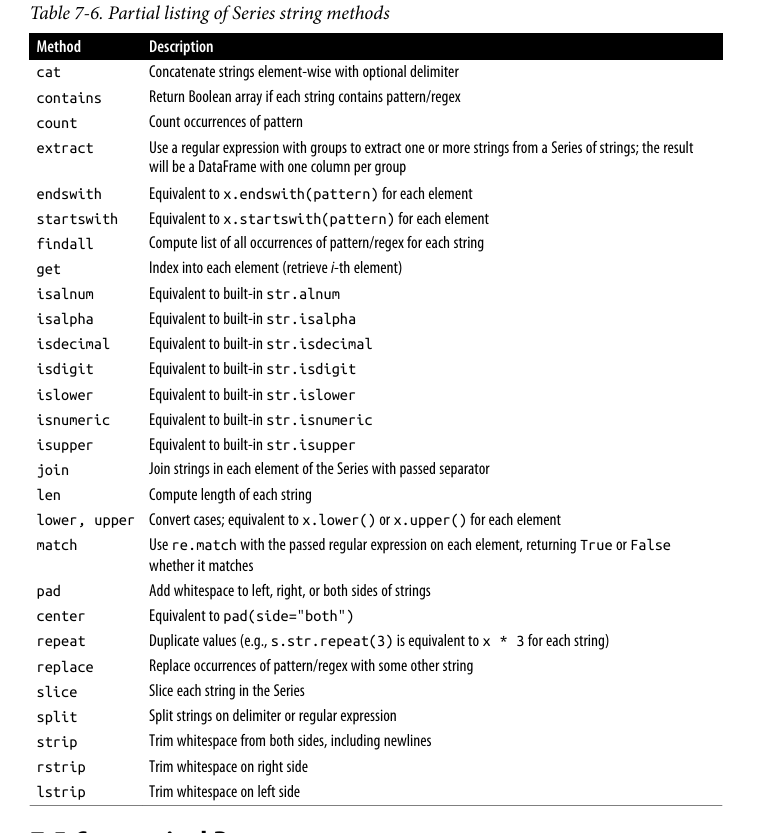